In [48]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import mlflow
import mlflow.keras

In [49]:
def get_data_extract():

    if "dataset" in os.listdir():
        print("Dataset exists")

    else:

        print("Downloading dataset")

        !wget -O food-data.zip https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset

        !mkdir dataset

        !unzip -q food-data.zip -d dataset

        print("Done")

get_data_extract()

Dataset exists


In [50]:
train_dir = "dataset/training"
val_dir = "dataset/validation"
test_dir = "dataset/evaluation"

## Dataset Preparation

Load images using TensorFlow dataset loader.

In [51]:
IMG_SIZE=(224,224)

BATCH=32

train_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

test_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

Found 9866 files belonging to 11 classes.
Found 3430 files belonging to 11 classes.
Found 3347 files belonging to 11 classes.


## Class Information

In [52]:
class_names=train_ds.class_names

num_classes=len(class_names)

print(class_names)

print(num_classes)

['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
11


## Data Augmentation

Apply augmentation to improve generalization.

In [53]:
data_aug=keras.Sequential([

keras.layers.RandomFlip("horizontal"),

keras.layers.RandomRotation(0.1),

keras.layers.RandomZoom(0.1)

])

## Performance Optimization

In [54]:
AUTOTUNE=tf.data.AUTOTUNE

train_ds=train_ds.prefetch(AUTOTUNE)

val_ds=val_ds.prefetch(AUTOTUNE)

test_ds=test_ds.prefetch(AUTOTUNE)

# Experiment 1: Feature Extraction

Freeze EfficientNet and train only classifier.

In [55]:
base_model=tf.keras.applications.EfficientNetB0(

include_top=False,

weights="imagenet",

input_shape=(224,224,3)

)

base_model.trainable=False

## Build Model

In [56]:
inputs=keras.Input(shape=(224,224,3))

x=data_aug(inputs)

x=tf.keras.applications.efficientnet.preprocess_input(x)

x=base_model(x,training=False)

x=keras.layers.GlobalAveragePooling2D()(x)

x=keras.layers.Dropout(0.3)(x)

outputs=keras.layers.Dense(num_classes,activation="softmax")(x)

model=keras.Model(inputs,outputs)

## Compile Model

In [57]:
model.compile(

optimizer=keras.optimizers.Adam(1e-3),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

## Callbacks

In [58]:
callbacks=[

keras.callbacks.EarlyStopping(

monitor="val_loss",

patience=3,

restore_best_weights=True

)]

## Train Feature Extraction Model

In [59]:
history_feature=model.fit(

train_ds,

validation_data=val_ds,

epochs=10,

callbacks=callbacks

)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - accuracy: 0.7168 - loss: 0.9341 - val_accuracy: 0.8300 - val_loss: 0.5370
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8261 - loss: 0.5459 - val_accuracy: 0.8528 - val_loss: 0.4519
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.8489 - loss: 0.4726 - val_accuracy: 0.8624 - val_loss: 0.4227
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 35s 114ms/step - accuracy: 0.8581 - loss: 0.4397 - val_accuracy: 0.8673 - val_loss: 0.4028
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8659 - loss: 0.4106 - val_accuracy: 0.8700 - val_loss: 0.3899
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 33s 108ms/step - accuracy: 0.8743 - loss: 0.3956 - val_accuracy: 0.8700 - val_loss: 0.3868
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.8751 - loss: 0.3837 - val_accuracy: 0.8735 - val_loss: 0.3701
Epoch 8/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8766 - loss: 0

## Evaluate Model

In [60]:
test_loss,test_acc=model.evaluate(test_ds)

print(test_acc)

105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9023 - loss: 0.3121
0.9023005962371826


## Plot Training Results

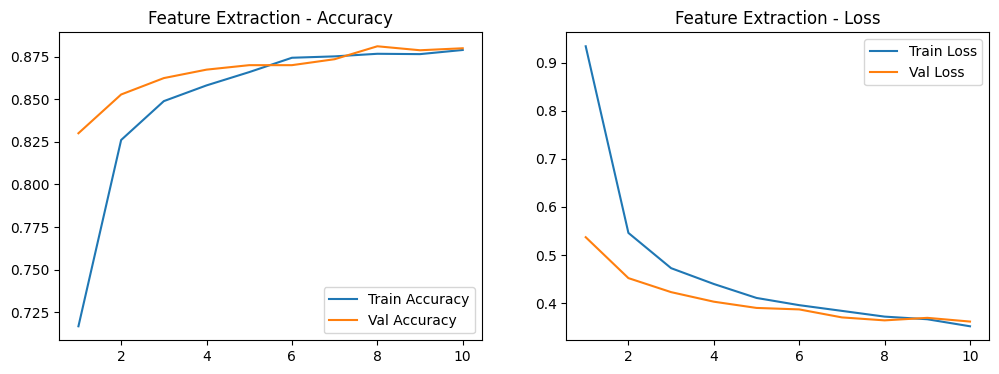

In [62]:
plot_history(history_feature,"Feature Extraction")

# Experiment 2: Fine Tuning

Unfreeze last layers and retrain.

In [64]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

## Recompile Model

In [65]:
model.compile(

optimizer=keras.optimizers.Adam(1e-5),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

## Fine Tuning Training

In [66]:
history_fine=model.fit(

train_ds,

validation_data=val_ds,

epochs=10,

callbacks=callbacks

)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 53s 133ms/step - accuracy: 0.7466 - loss: 0.7807 - val_accuracy: 0.8490 - val_loss: 0.4799
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 38s 123ms/step - accuracy: 0.7957 - loss: 0.6230 - val_accuracy: 0.8583 - val_loss: 0.4486
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8304 - loss: 0.5337 - val_accuracy: 0.8627 - val_loss: 0.4233


In [67]:
test_loss_fine, test_acc_fine = model.evaluate(test_ds)
print("Fine Tuning Test Loss:", test_loss_fine)
print("Fine Tuning Test Accuracy:", test_acc_fine)

105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.8670 - loss: 0.4247
Fine Tuning Test Loss: 0.4246671497821808
Fine Tuning Test Accuracy: 0.8670451045036316


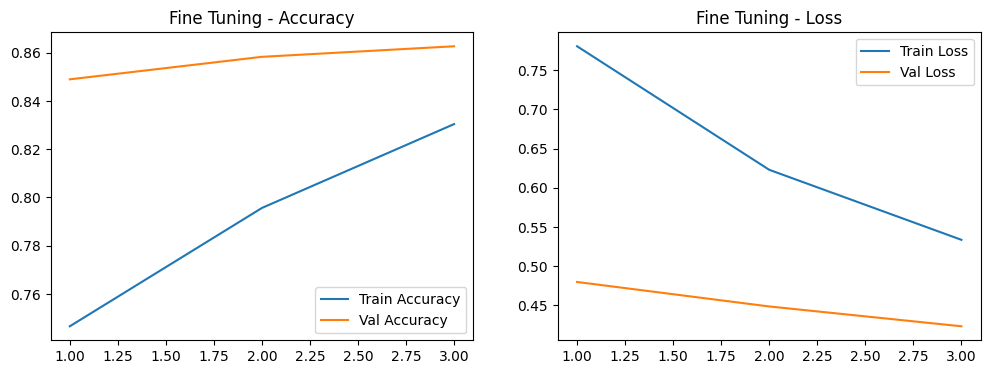

In [68]:
plot_history(history_fine, "Fine Tuning")

In [69]:
print("Feature Extraction Test Accuracy:", test_acc)
print("Fine Tuning Test Accuracy:", test_acc_fine)

Feature Extraction Test Accuracy: 0.9023005962371826
Fine Tuning Test Accuracy: 0.8670451045036316


## Gradual Unfreezing

In [71]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_stage = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.7933 - loss: 0.6354 - val_accuracy: 0.8519 - val_loss: 0.4659
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - accuracy: 0.8081 - loss: 0.5897 - val_accuracy: 0.8571 - val_loss: 0.4453
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.8285 - loss: 0.5436 - val_accuracy: 0.8601 - val_loss: 0.4317
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.8303 - loss: 0.5282 - val_accuracy: 0.8641 - val_loss: 0.4202
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - accuracy: 0.8373 - loss: 0.5069 - val_accuracy: 0.8671 - val_loss: 0.4106


## MLflow

In [73]:
mlflow.set_experiment("Food11 Transfer Learning")

with mlflow.start_run():

    mlflow.log_param("architecture","EfficientNetB0")

    mlflow.log_param("feature_extraction_epochs",8)

    mlflow.log_param("fine_tuning_epochs",5)

    mlflow.log_metric("feature_extraction_accuracy", test_acc)

    mlflow.log_metric("fine_tuning_accuracy", test_acc_fine)

    mlflow.keras.log_model(model,"final_model")

print("MLflow tracking complete")

2026/03/14 09:47:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/14 09:47:12 INFO mlflow.store.db.utils: Updating database tables
2026/03/14 09:47:13 INFO mlflow.tracking.fluent: Experiment with name 'Food11 Transfer Learning' does not exist. Creating a new experiment.
2026/03/14 09:47:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 09:47:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MLflow tracking complete


In [99]:

import os
import mlflow
import mlflow.keras
import dagshub

DAGSHUB_USER = "Majid-Alnodali"
DAGSHUB_REPO = "food11-transfer-learning"
DAGSHUB_TOKEN = DAGSHUB_TOKEN

os.environ["MLFLOW_TRACKING_USERNAME"] = "Majid-Alnodali"
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
os.environ["DAGSHUB_USER_TOKEN"] = DAGSHUB_TOKEN

mlflow.set_tracking_uri(
f"https://dagshub.com/{"Majid-Alnodali"}/{"food11-transfer-learning"}.mlflow"
)

mlflow.set_experiment("Food11 Transfer Learning")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Setup complete")

2026/03/14 10:33:18 INFO mlflow.tracking.fluent: Experiment with name 'Food11 Transfer Learning' does not exist. Creating a new experiment.


Tracking URI: https://dagshub.com/Majid-Alnodali/food11-transfer-learning.mlflow
Setup complete


In [101]:
with mlflow.start_run(run_name="EfficientNetB0_Fine_Tuning"):

    mlflow.log_param("architecture", "EfficientNetB0")
    mlflow.log_param("feature_extraction_epochs", 10)
    mlflow.log_param("fine_tuning_epochs", 10)
    mlflow.log_param("unfrozen_layers", 20)

    mlflow.log_metric("feature_extraction_accuracy", float(test_acc))
    mlflow.log_metric("fine_tuning_accuracy", float(test_acc_fine))
    mlflow.log_metric("fine_tuning_loss", float(test_loss_fine))

    mlflow.keras.log_model(model, "final_model")

print("Run logged successfully")

2026/03/14 10:37:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 10:37:36 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run EfficientNetB0_Fine_Tuning at: https://dagshub.com/Majid-Alnodali/food11-transfer-learning.mlflow/#/experiments/0/runs/7f5635d2e2c24822ba06ed77d7fd9da0
🧪 View experiment at: https://dagshub.com/Majid-Alnodali/food11-transfer-learning.mlflow/#/experiments/0
Run logged successfully


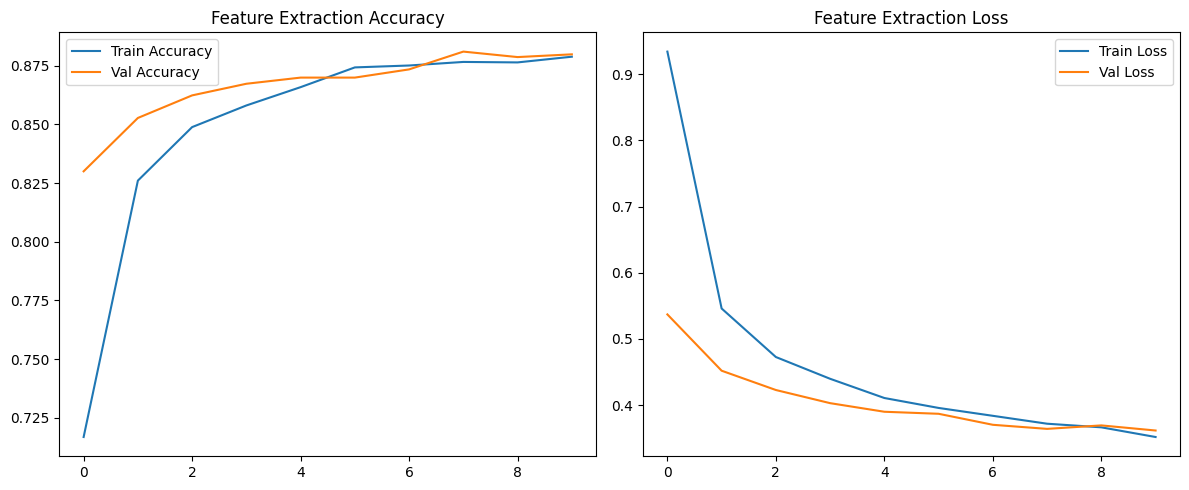

In [102]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_feature.history["accuracy"], label="Train Accuracy")
plt.plot(history_feature.history["val_accuracy"], label="Val Accuracy")
plt.title("Feature Extraction Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_feature.history["loss"], label="Train Loss")
plt.plot(history_feature.history["val_loss"], label="Val Loss")
plt.title("Feature Extraction Loss")
plt.legend()

plt.tight_layout()
plt.savefig("feature_extraction_plot.png")
plt.show()

In [103]:
with mlflow.start_run(run_name="Artifacts_Upload"):
    mlflow.log_artifact("feature_extraction_plot.png")

🏃 View run Artifacts_Upload at: https://dagshub.com/Majid-Alnodali/food11-transfer-learning.mlflow/#/experiments/0/runs/ffc25de92ebc4fc3b86dedf957aa373f
🧪 View experiment at: https://dagshub.com/Majid-Alnodali/food11-transfer-learning.mlflow/#/experiments/0
